<a href="https://colab.research.google.com/github/meghana507/ai-ml-practice-project/blob/main/Male_female.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steps to solve Emergency vs Non-Emergency vehicle classification problem

<ol>1. Loading the dataset</ol>
<ol>2. Pre-processing the data</ol>
<ol>3. Creating training and validation set</ol>
<ol>4. Defining the model architecture</ol>
<ol>5. Compiling the model</ol>
<ol>6. Training the model</ol>
<ol>7. Evaluating model performance</ol>

## 1. Loading the dataset

In [1]:
# import necessary libraries and functions
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
%matplotlib inline

from keras.layers import Dense, InputLayer
from keras.models import Sequential

from sklearn.model_selection import train_test_split
from PIL import Image # Import Image for resizing

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip /content/drive/MyDrive/photo.zip

Streaming output truncated to the last 5000 lines.
  inflating: photo/5249.jpg          
  inflating: photo/5250.jpg          
  inflating: photo/5251.jpg          
  inflating: photo/5252.jpg          
  inflating: photo/5253.jpg          
  inflating: photo/5254.jpg          
  inflating: photo/5255.jpg          
  inflating: photo/5256.jpg          
  inflating: photo/5257.jpg          
  inflating: photo/5258.jpg          
  inflating: photo/5259.jpg          
  inflating: photo/5260.jpg          
  inflating: photo/5261.jpg          
  inflating: photo/5262.jpg          
  inflating: photo/5263.jpg          
  inflating: photo/5264.jpg          
  inflating: photo/5265.jpg          
  inflating: photo/5266.jpg          
  inflating: photo/5267.jpg          
  inflating: photo/5268.jpg          
  inflating: photo/5269.jpg          
  inflating: photo/5270.jpg          
  inflating: photo/5271.jpg          
  inflating: photo/5272.jpg          
  inflating: photo/5273.jpg          

In [7]:
# reading the csv file
data = pd.read_csv('/content/train.csv')

In [8]:
# create random number generator
seed = 42
rng = np.random.RandomState(seed)

In [9]:
# looking at first five rows of the data
data.head()

,image_names,class
0,11413.jpg,1
1,9863.jpg,1
2,997.jpg,0
3,5950.jpg,0
4,10454.jpg,1


In [10]:
# distribution of classes in the dataset
data['class'].value_counts()

,count
class,
1,6174
0,6022


In [11]:
# load images and store it in numpy array

# define target image size
TARGET_SIZE = (64, 64)

# empty list to store the images
X = []
# iterating over each image
for img_name in data.image_names:
    # loading the image using its name
    img_path = 'photo/' + img_name
    img = Image.open(img_path) # Open image with PIL
    img = img.resize(TARGET_SIZE) # Resize image
    img_array = np.array(img) # Convert back to numpy array
    # saving each image in the list
    X.append(img_array)

# converting the list of images into array
X=np.array(X)

# storing the target variable in separate variable
y = data['class'].values

In [12]:
# shape of the image
X.shape

(12196, 64, 64, 3)

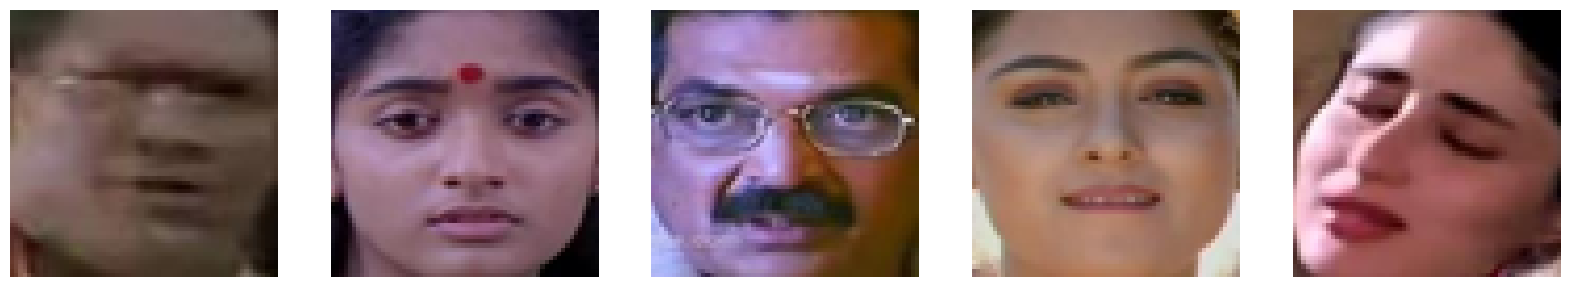

In [13]:
# visualizing images
fig,ax = plt.subplots(nrows=1,ncols=5,figsize=(20,20))
for i in range(5):
    ax[i].imshow(X[i*400])
    ax[i].axis('off')

## 2. Pre-processing the data

![alt text](https://drive.google.com/uc?id=1qrMvsKOgTmo4Zt93r8G84Z5I_2IfVduq)

In [14]:
# converting 3 dimensional image to 1 dimensional image
X = X.reshape(X.shape[0], TARGET_SIZE[0] * TARGET_SIZE[1] * 3)
X.shape

(12196, 12288)

In [15]:
# minimum and maximum pixel values of images
X.min(), X.max()

(np.uint8(0), np.uint8(255))

In [16]:
# normalizing the pixel values
X = X / X.max()

In [17]:
# minimum and maximum pixel values of images after normalizing
X.min(), X.max()

(np.float64(0.0), np.float64(1.0))

## 3. Creating training and validation set

In [18]:
# creating a training and validation set
X_train, X_valid, y_train, y_valid=train_test_split(X,y,test_size=0.3, random_state=seed)

In [19]:
# shape of training and validation set
(X_train.shape, y_train.shape), (X_valid.shape, y_valid.shape)

(((8537, 12288), (8537,)), ((3659, 12288), (3659,)))

## 4. Defining the model architecture

In [20]:
# defining the architecture of the model
model=Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [21]:
# summary of the model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 100)            │     1,228,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,229,001 (4.69 MB)

 Trainable params: 1,229,001 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compiling the model

In [22]:
# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

## 6. Training the model

In [23]:
# training the model
model_history = model.fit(X_train, y_train, epochs=50, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6043 - loss: 0.6776 - val_accuracy: 0.6805 - val_loss: 0.6475
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6908 - loss: 0.6369 - val_accuracy: 0.6865 - val_loss: 0.6278
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7093 - loss: 0.6107 - val_accuracy: 0.7100 - val_loss: 0.6083
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7257 - loss: 0.5927 - val_accuracy: 0.7108 - val_loss: 0.5908
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7215 - loss: 0.5790 - val_accuracy: 0.7221 - val_loss: 0.5839
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7228 - loss: 0.5667 - val_accuracy: 0.7240 - val_loss: 0.5709
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7323 - loss: 0.5607 - val_accuracy: 0.7289 - val_loss: 0.5627
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7324 - loss: 0.5555 - val_accuracy: 0.7283 - val

## 7. Evaluating model performance

In [24]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]

115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [26]:
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(int)

In [27]:
# accuracy on validation set
from sklearn.metrics import accuracy_score
print('Accuracy on validation set:', accuracy_score(y_valid, prediction_int), '%')

Accuracy on validation set: 0.7767149494397376 %


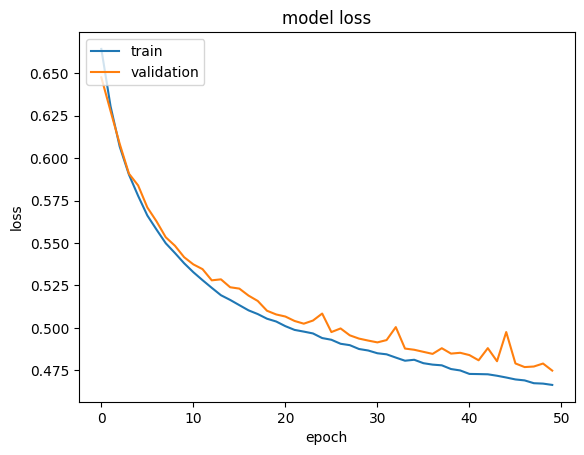

In [28]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

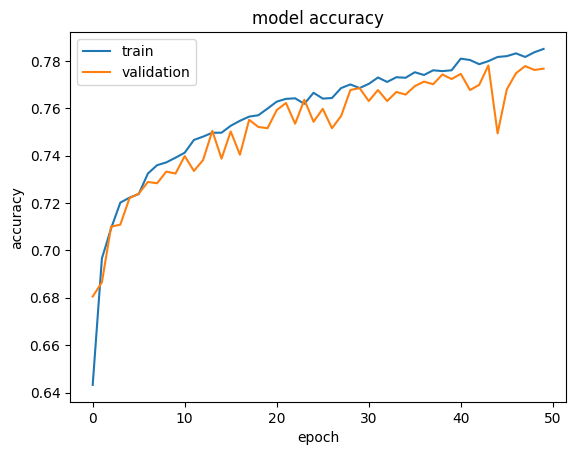

In [29]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


# Hyperparameter tuning of neural networks

<ol>1. change activation function of hidden layer</ol>
<ol>2. increase hidden neurons</ol>
<ol>3. increase hidden layers</ol>
<ol>4. increase number of epochs</ol>
<ol>5. change optimizer</ol>

### 1. Changing activation function of hidden layer

In [31]:
# using relu as activation function in hidden layer
model=Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))
model.add(Dense(100, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

IndexError: tuple index out of range

In [ ]:
# summary of the model
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 100)               15052900  
                                                                 
 dense_6 (Dense)             (None, 1)                 101       
                                                                 
Total params: 15,053,001
Trainable params: 15,053,001
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# training the model for 50 epochs
model_history = model.fit(X_train, y_train, epochs=50, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/50
13/13 [==============================] - 2s 134ms/step - loss: 1.4517 - accuracy: 0.5784 - val_loss: 0.6911 - val_accuracy: 0.5779
Epoch 2/50
13/13 [==============================] - 1s 59ms/step - loss: 0.6605 - accuracy: 0.5923 - val_loss: 0.6808 - val_accuracy: 0.5609
Epoch 3/50
13/13 [==============================] - 1s 61ms/step - loss: 0.6524 - accuracy: 0.6209 - val_loss: 0.7215 - val_accuracy: 0.4660
Epoch 4/50
13/13 [==============================] - 1s 61ms/step - loss: 0.6447 - accuracy: 0.6069 - val_loss: 0.6218 - val_accuracy: 0.6771
Epoch 5/50
13/13 [==============================] - 1s 59ms/step - loss: 0.6348 - accuracy: 0.6549 - val_loss: 0.6076 - val_accuracy: 0.6827
Epoch 6/50
13/13 [==============================] - 1s 60ms/step - loss: 0.6572 - accuracy: 0.6446 - val_loss: 0.6123 - val_accuracy: 0.6742
Epoch 7/50
13/13 [==============================] - 1s 60ms/step - loss: 0.5945 - accuracy: 0.7029 - val_loss: 0.6275 - val_accuracy: 0.6331
Epoch 8/50
1

In [ ]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(np.int)

23/23 [==============================] - 0s 11ms/step


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid,prediction_int), '%')

Accuracy on validation set: 0.6869688385269122 %


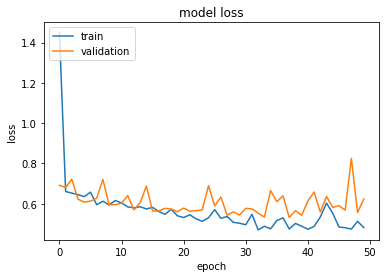

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 2. Increasing hidden neurons

In [ ]:
# increase hidden neurons
model=Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))
model.add(Dense(1024, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
# model summary
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              154141696 
                                                                 
 dense_1 (Dense)             (None, 1)                 1025      
                                                                 
Total params: 154,142,721
Trainable params: 154,142,721
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_history = model.fit(X_train, y_train, epochs=50, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/50
13/13 [==============================] - 4s 143ms/step - loss: 1.5253 - accuracy: 0.5176 - val_loss: 0.7579 - val_accuracy: 0.5623
Epoch 2/50
13/13 [==============================] - 1s 82ms/step - loss: 0.7061 - accuracy: 0.5820 - val_loss: 0.6549 - val_accuracy: 0.5921
Epoch 3/50
13/13 [==============================] - 1s 82ms/step - loss: 0.6289 - accuracy: 0.6434 - val_loss: 0.6641 - val_accuracy: 0.5836
Epoch 4/50
13/13 [==============================] - 1s 83ms/step - loss: 0.6155 - accuracy: 0.6665 - val_loss: 0.6292 - val_accuracy: 0.6317
Epoch 5/50
13/13 [==============================] - 1s 82ms/step - loss: 0.6280 - accuracy: 0.6598 - val_loss: 0.7383 - val_accuracy: 0.5722
Epoch 6/50
13/13 [==============================] - 1s 101ms/step - loss: 0.6708 - accuracy: 0.6130 - val_loss: 0.5897 - val_accuracy: 0.6955
Epoch 7/50
13/13 [==============================] - 1s 109ms/step - loss: 0.5931 - accuracy: 0.6938 - val_loss: 0.5839 - val_accuracy: 0.6898
Epoch 8/50

In [ ]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(np.int)

23/23 [==============================] - 0s 13ms/step


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, prediction_int), '%')

Accuracy on validation set: 0.6303116147308782 %


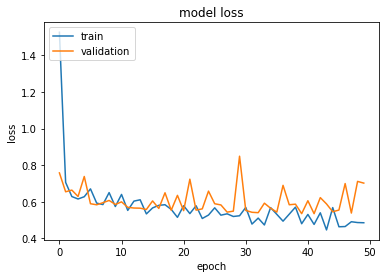

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 3. Increasing hidden layers

In [ ]:
# increase hidden layers
model=Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

# compiling the model
model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
# model summary
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 100)               15052900  
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 1)                 101       
                                                                 
Total params: 15,063,101
Trainable params: 15,063,101
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_history = model.fit(X_train, y_train, epochs=50, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/50
13/13 [==============================] - 3s 169ms/step - loss: 0.6851 - accuracy: 0.5565 - val_loss: 0.6759 - val_accuracy: 0.5609
Epoch 2/50
13/13 [==============================] - 1s 62ms/step - loss: 0.6642 - accuracy: 0.5954 - val_loss: 0.6674 - val_accuracy: 0.5637
Epoch 3/50
13/13 [==============================] - 1s 60ms/step - loss: 0.6527 - accuracy: 0.6142 - val_loss: 0.6511 - val_accuracy: 0.6586
Epoch 4/50
13/13 [==============================] - 1s 60ms/step - loss: 0.6453 - accuracy: 0.6507 - val_loss: 0.6446 - val_accuracy: 0.6388
Epoch 5/50
13/13 [==============================] - 1s 60ms/step - loss: 0.6389 - accuracy: 0.6464 - val_loss: 0.6369 - val_accuracy: 0.6615
Epoch 6/50
13/13 [==============================] - 1s 62ms/step - loss: 0.6333 - accuracy: 0.6683 - val_loss: 0.6326 - val_accuracy: 0.6586
Epoch 7/50
13/13 [==============================] - 1s 60ms/step - loss: 0.6280 - accuracy: 0.6640 - val_loss: 0.6284 - val_accuracy: 0.6601
Epoch 8/50
1

In [ ]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(np.int)

23/23 [==============================] - 0s 10ms/step


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid,prediction_int), '%')

Accuracy on validation set: 0.6940509915014165 %


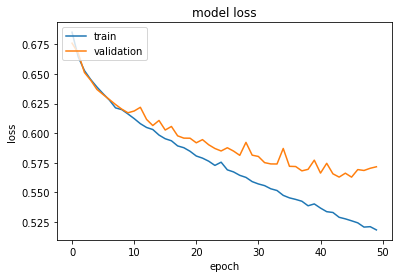

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 4. Increasing number of epochs

In [ ]:
# increase number of epochs
model=Sequential()
model.add(InputLayer(input_shape=(X_train.shape[1],)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer="sgd", metrics=['accuracy'])

In [ ]:
# model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               15052900  
                                                                 
 dense_1 (Dense)             (None, 1)                 101       
                                                                 
Total params: 15,053,001
Trainable params: 15,053,001
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_history = model.fit(X_train, y_train, epochs=100, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/100
13/13 [==============================] - 4s 165ms/step - loss: 0.8180 - accuracy: 0.5826 - val_loss: 0.6489 - val_accuracy: 0.5949
Epoch 2/100
13/13 [==============================] - 1s 84ms/step - loss: 0.6485 - accuracy: 0.6154 - val_loss: 0.6437 - val_accuracy: 0.6034
Epoch 3/100
13/13 [==============================] - 1s 74ms/step - loss: 0.6326 - accuracy: 0.6440 - val_loss: 0.6376 - val_accuracy: 0.6317
Epoch 4/100
13/13 [==============================] - 1s 72ms/step - loss: 0.6231 - accuracy: 0.6580 - val_loss: 0.6334 - val_accuracy: 0.6374
Epoch 5/100
13/13 [==============================] - 1s 87ms/step - loss: 0.6235 - accuracy: 0.6440 - val_loss: 0.6321 - val_accuracy: 0.6431
Epoch 6/100
13/13 [==============================] - 1s 84ms/step - loss: 0.5911 - accuracy: 0.7066 - val_loss: 0.5858 - val_accuracy: 0.6955
Epoch 7/100
13/13 [==============================] - 1s 79ms/step - loss: 0.5946 - accuracy: 0.6865 - val_loss: 0.5868 - val_accuracy: 0.6997
Epoch

In [ ]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(np.int)

23/23 [==============================] - 0s 10ms/step


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, prediction_int), '%')

Accuracy on validation set: 0.726628895184136 %


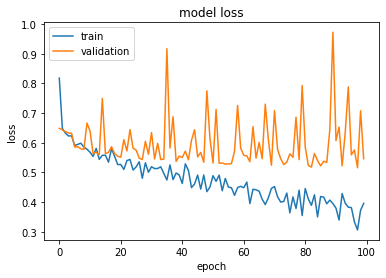

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 5. Changing the optimizer

In [ ]:
# importing adam optimizer from keras optimizer module
from keras.optimizers import Adam

In [ ]:
# defining the adam optimizer and setting the learning rate as 10^-5
adam = Adam(lr=1e-5)

/usr/local/lib/python3.7/dist-packages/keras/optimizers/optimizer_v2/adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [5]:
# change optimizer
model=Sequential()

model.add(InputLayer(input_shape=(TARGET_SIZE[0] * TARGET_SIZE[1] * 3,)))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(100, activation='sigmoid'))
model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


NameError: name 'adam' is not defined

In [ ]:
# model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 100)               15052900  
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 1)                 101       
                                                                 
Total params: 15,063,101
Trainable params: 15,063,101
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_history = model.fit(X_train, y_train, epochs=100, batch_size=128,validation_data=(X_valid,y_valid))

Epoch 1/100
13/13 [==============================] - 2s 117ms/step - loss: 0.6660 - accuracy: 0.5948 - val_loss: 0.6589 - val_accuracy: 0.5694
Epoch 2/100
13/13 [==============================] - 1s 65ms/step - loss: 0.6385 - accuracy: 0.6349 - val_loss: 0.6355 - val_accuracy: 0.6431
Epoch 3/100
13/13 [==============================] - 1s 63ms/step - loss: 0.6241 - accuracy: 0.6665 - val_loss: 0.6215 - val_accuracy: 0.6586
Epoch 4/100
13/13 [==============================] - 1s 62ms/step - loss: 0.6123 - accuracy: 0.6731 - val_loss: 0.6141 - val_accuracy: 0.6657
Epoch 5/100
13/13 [==============================] - 1s 64ms/step - loss: 0.6037 - accuracy: 0.6883 - val_loss: 0.6076 - val_accuracy: 0.6742
Epoch 6/100
13/13 [==============================] - 1s 63ms/step - loss: 0.5965 - accuracy: 0.7096 - val_loss: 0.6118 - val_accuracy: 0.6657
Epoch 7/100
13/13 [==============================] - 1s 63ms/step - loss: 0.5888 - accuracy: 0.7205 - val_loss: 0.5989 - val_accuracy: 0.6884
Epoch

In [ ]:
# getting predictions in the form of class as well as probabilities

predictions = model.predict(X_valid)[:, 0]
prediction = predictions.reshape(-1,)

# converting probabilities to classes
prediction_int = prediction >= 0.5
prediction_int = prediction_int.astype(np.int)

23/23 [==============================] - 0s 11ms/step


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [ ]:
# accuracy on validation set
print('Accuracy on validation set:', accuracy_score(y_valid, prediction_int), '%')

Accuracy on validation set: 0.7181303116147308 %


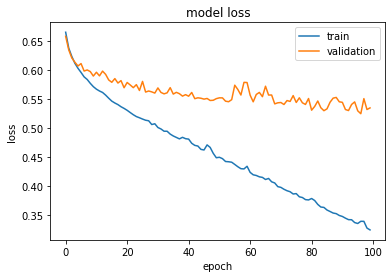

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

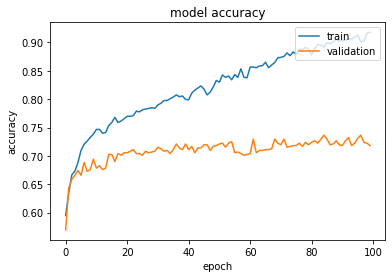

In [ ]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()